# Поиск похожих отрезков временных рядов

Демонстрация класса `TimeSeriesSubsequenceSearcher`: загружаем CSV, приводим ряды к общей частоте, вырезаем query-отрезок по времени и визуально сравниваем его с найденными похожими отрезками в других рядах.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from find_similar import TimeSeriesSubsequenceSearcher

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

## Загрузка и легкая препарировка данных

Берем все файлы `time_series*.csv`. Чтобы графики оставались читаемыми и поиск шел быстрее, оставляем последние несколько недель каждого ряда.

In [2]:
def parse_timestamp_column(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    unit = "ms" if numeric.abs().max() >= 1e11 else "s"
    return pd.to_datetime(values, unit=unit, utc=True).dt.tz_convert(None)


def trim_last_weeks(df: pd.DataFrame, weeks: int = 6) -> pd.DataFrame:
    timestamps = parse_timestamp_column(df["timestamp"])
    cutoff = timestamps.max() - pd.Timedelta(weeks=weeks)
    return df.loc[timestamps >= cutoff].copy()


paths = sorted(Path(".").glob("time_series*.csv"))
series_dict = {path.stem: trim_last_weeks(pd.read_csv(path), weeks=6) for path in paths}

summary = pd.DataFrame(
    {
        "series_id": list(series_dict),
        "rows": [len(df) for df in series_dict.values()],
        "columns": [", ".join(df.columns) for df in series_dict.values()],
    }
)
summary

,series_id,rows,columns
0,time_series,9216,"timestamp, value_0"
1,time_series_2,1723,"timestamp, value, ground_truth, predicted"
2,time_series_3,1723,"timestamp, value, ground_truth, predicted"
3,time_series_4,1924,"timestamp, value, ground_truth, predicted"
4,time_series_5,1840,"timestamp, value, ground_truth, predicted"
5,time_series_6,1849,"timestamp, value, ground_truth, predicted"


## Resampling и построение поискового индекса

Для бинарных рядов из примера удобно использовать шаг `30min`. Если важны более короткие паттерны, можно заменить `freq` на `5min` или включить авто-вывод частоты через `freq=None`.

In [3]:
searcher = TimeSeriesSubsequenceSearcher(
    freq="30min",
    agg="mean",
    interpolate_limit=3,
    normalize=True,
    exclusion_fraction=0.75,
)

searcher.fit(series_dict)

prepared_summary = pd.DataFrame(
    {
        "series_id": list(searcher.prepared_series_),
        "prepared_points": [len(series) for series in searcher.prepared_series_.values()],
        "missing": [int(series.isna().sum()) for series in searcher.prepared_series_.values()],
        "start": [series.index.min() for series in searcher.prepared_series_.values()],
        "end": [series.index.max() for series in searcher.prepared_series_.values()],
    }
)
prepared_summary

,series_id,prepared_points,missing,start,end
0,time_series,1536,0,2025-08-03 00:00:00,2025-09-03 23:30:00
1,time_series_2,2017,71,2025-07-22 17:00:00,2025-09-02 17:00:00
2,time_series_3,2017,71,2025-07-22 17:00:00,2025-09-02 17:00:00
3,time_series_4,2017,32,2025-07-22 21:30:00,2025-09-02 21:30:00
4,time_series_5,2017,60,2025-07-22 15:30:00,2025-09-02 15:30:00
5,time_series_6,2017,41,2025-07-22 13:00:00,2025-09-02 13:00:00


## Выбор query-отрезка

Берем 12-часовой отрезок из `time_series_2`. Чтобы пример не оказался плоским участком из одних нулей, выбираем окно с максимальной rolling-std.

In [4]:
source_series_id = "time_series_2" if "time_series_2" in searcher.prepared_series_ else next(iter(searcher.prepared_series_))
query_points = 24  # 24 points * 30min = 12 hours

source_series = searcher.prepared_series_[source_series_id]
rolling_std = source_series.rolling(query_points).std().to_numpy()

if np.isfinite(rolling_std).any():
    query_end_idx = int(np.nanargmax(rolling_std))
    query_start_idx = query_end_idx - query_points + 1
else:
    query_start_idx = min(max(int(len(source_series) * 0.65), 0), len(source_series) - query_points)
    query_end_idx = query_start_idx + query_points - 1

query_start_idx = max(query_start_idx, 0)
query_end_idx = min(query_start_idx + query_points - 1, len(source_series) - 1)
query_start_time = source_series.index[query_start_idx]
query_end_time = source_series.index[query_end_idx]
query = source_series.iloc[query_start_idx : query_end_idx + 1]

query_start_time, query_end_time, len(query), float(query.std())

(Timestamp('2025-07-26 01:30:00'),
 Timestamp('2025-07-26 13:00:00'),
 24,
 132.7321319070093)

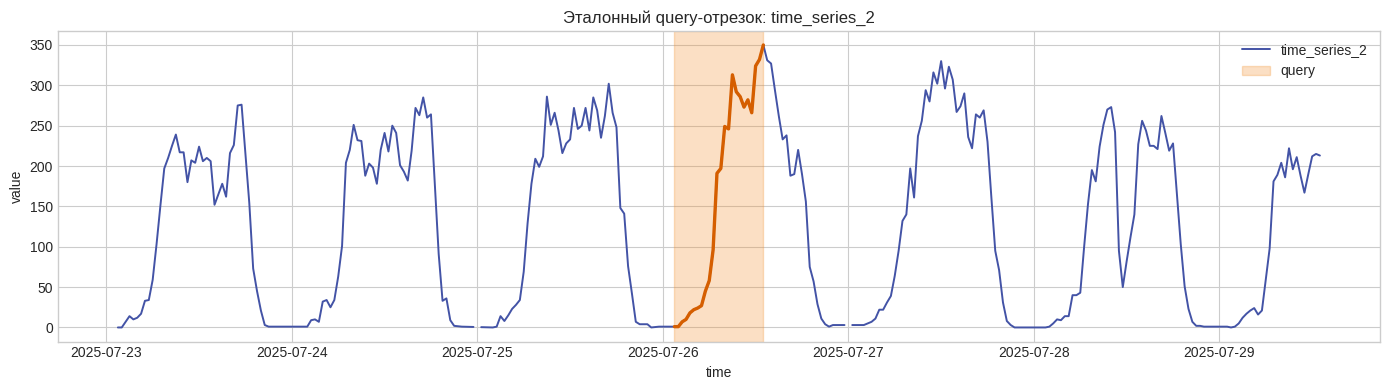

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

context_start = query_start_time - pd.Timedelta(days=3)
context_end = query_end_time + pd.Timedelta(days=3)
context = source_series.loc[context_start:context_end]

ax.plot(context.index, context.values, color="#4353a6", linewidth=1.4, label=source_series_id)
ax.axvspan(query_start_time, query_end_time, color="#f28e2b", alpha=0.28, label="query")
ax.plot(query.index, query.values, color="#d55e00", linewidth=2.4)
ax.set_title(f"Эталонный query-отрезок: {source_series_id}")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.legend(loc="upper right")
plt.tight_layout()

## Поиск похожих отрезков в других рядах

In [6]:
results = searcher.search_by_time_range(
    source_series_id=source_series_id,
    start_time=query_start_time,
    end_time=query_end_time,
    top_k=8,
    search_in_source=False,
)

results

,series_id,start_idx,end_idx,start_time,end_time,distance
0,time_series_3,161,184,2025-07-26 01:30:00,2025-07-26 13:00:00,0.000000
1,time_series_5,786,809,2025-08-08 00:30:00,2025-08-08 12:00:00,0.517902
2,time_series_3,1600,1623,2025-08-25 01:00:00,2025-08-25 12:30:00,0.635830
3,time_series_3,881,904,2025-08-10 01:30:00,2025-08-10 13:00:00,0.657821
4,time_series_5,834,857,2025-08-09 00:30:00,2025-08-09 12:00:00,0.686994
5,time_series_5,546,569,2025-08-03 00:30:00,2025-08-03 12:00:00,0.694709
6,time_series_5,1794,1817,2025-08-29 00:30:00,2025-08-29 12:00:00,0.701763
7,time_series_3,929,952,2025-08-11 01:30:00,2025-08-11 13:00:00,0.730510


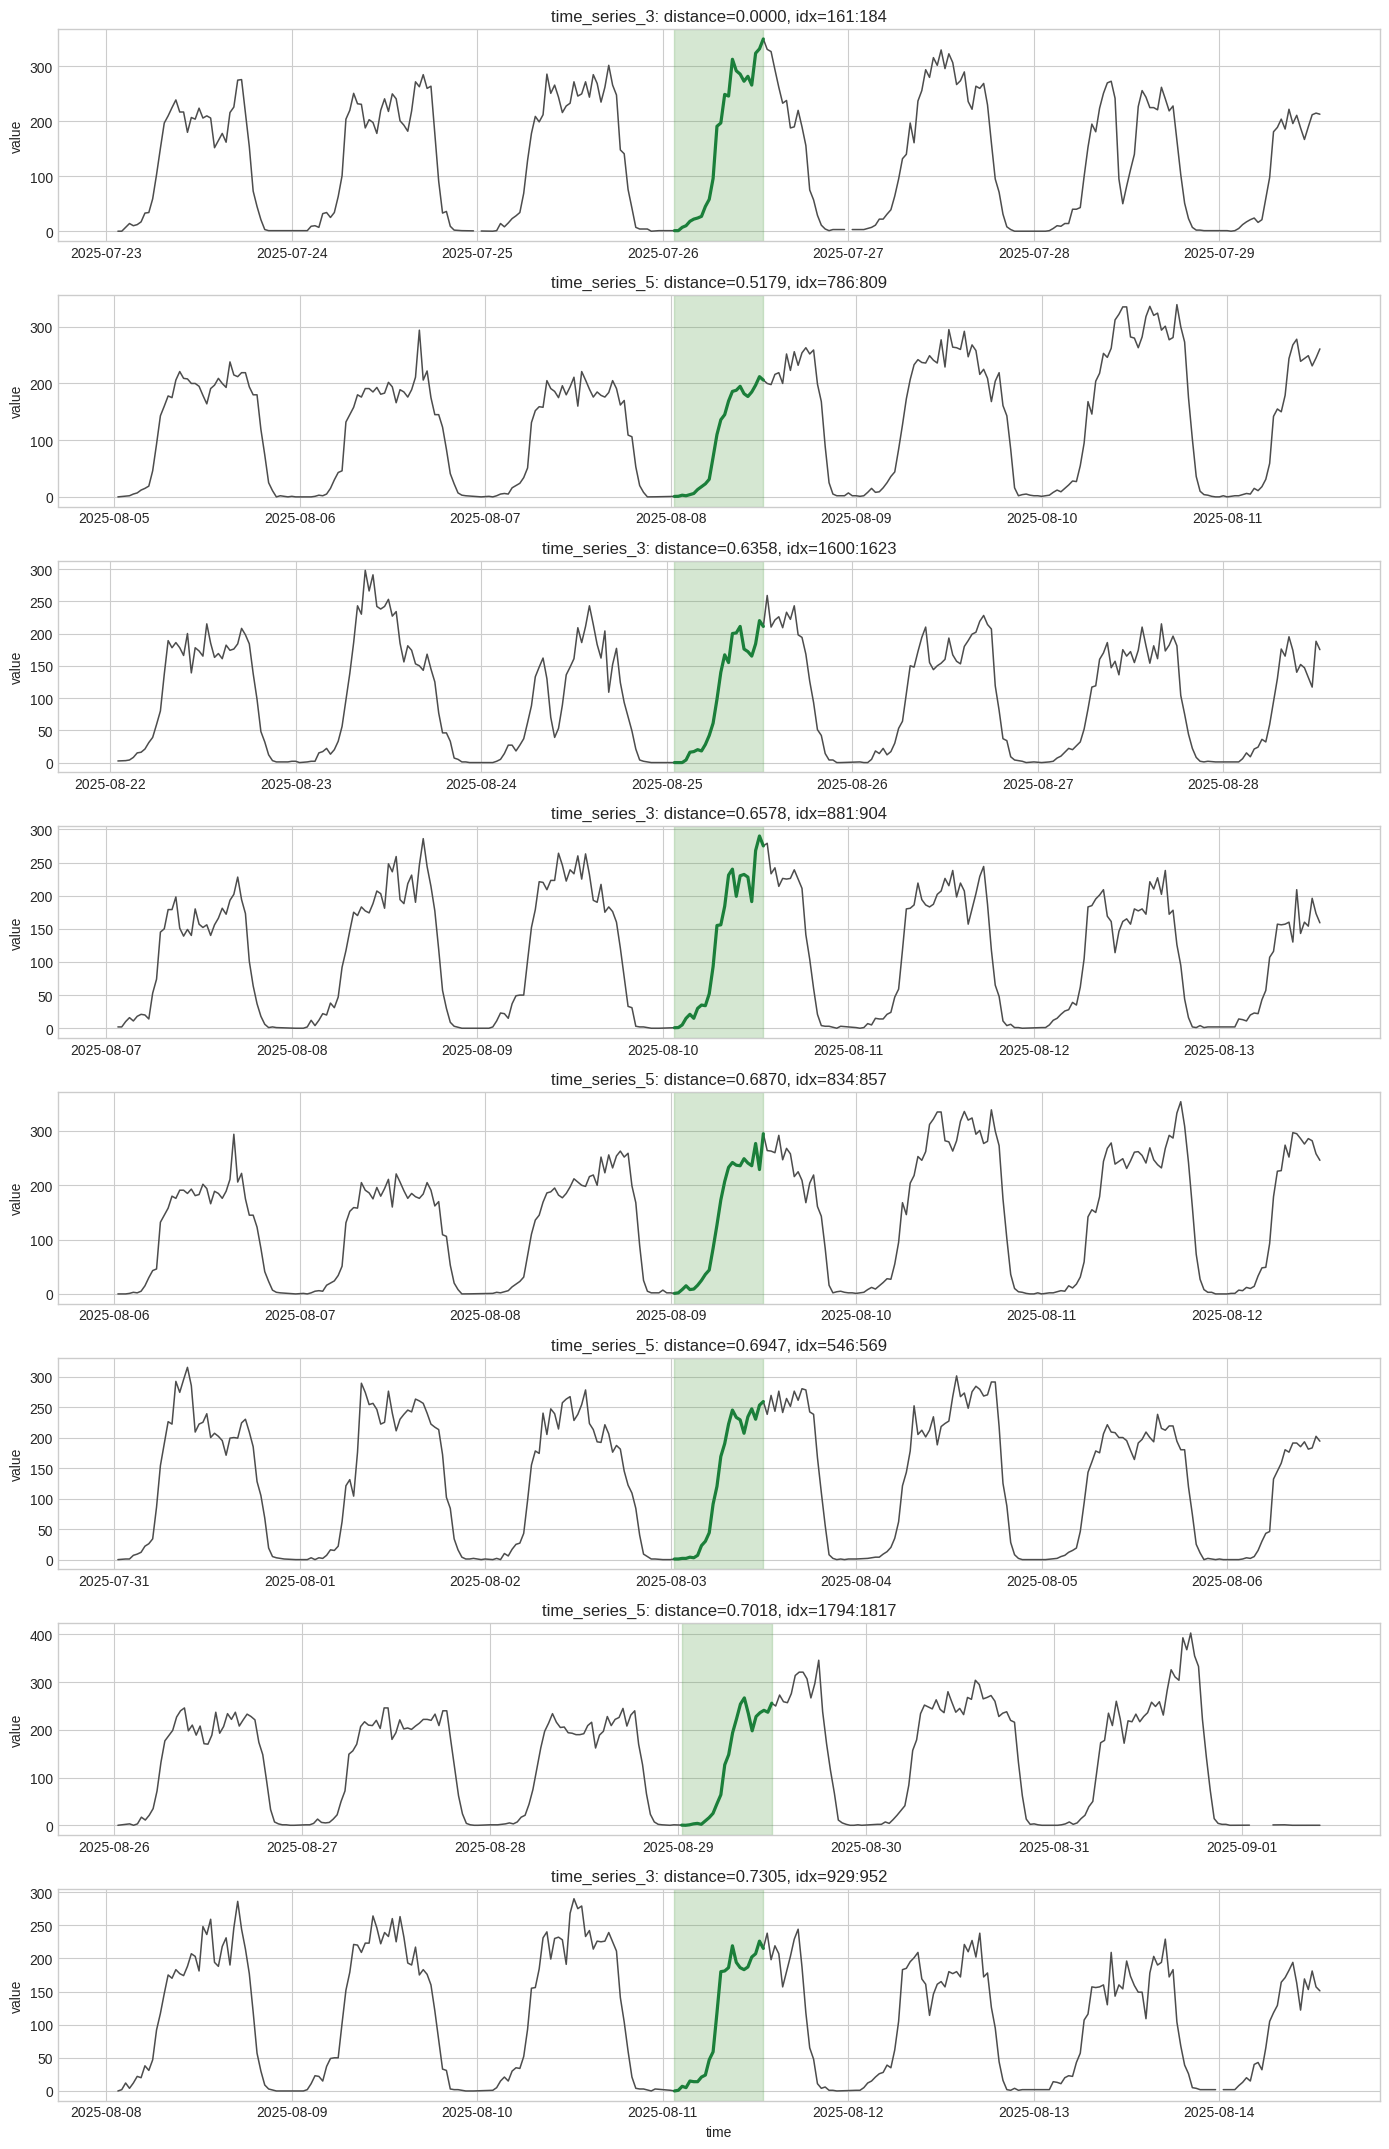

In [7]:
nrows = max(len(results), 1)
fig, axes = plt.subplots(nrows, 1, figsize=(14, 2.7 * nrows), sharex=False)
axes = np.atleast_1d(axes)

if results.empty:
    axes[0].text(0.5, 0.5, "No matches found", ha="center", va="center", transform=axes[0].transAxes)
    axes[0].set_axis_off()
else:
    for ax, row in zip(axes, results.itertuples(index=False)):
        target_series = searcher.prepared_series_[row.series_id]
        segment = searcher.get_segment(row.series_id, int(row.start_idx), int(row.end_idx))
        context = target_series.loc[row.start_time - pd.Timedelta(days=3): row.end_time + pd.Timedelta(days=3)]

        ax.plot(context.index, context.values, color="#4d4d4d", linewidth=1.1)
        ax.axvspan(row.start_time, row.end_time, color="#59a14f", alpha=0.25)
        ax.plot(segment.index, segment.values, color="#1b7f3a", linewidth=2.3)
        ax.set_title(f"{row.series_id}: distance={row.distance:.4f}, idx={row.start_idx}:{row.end_idx}")
        ax.set_ylabel("value")

axes[-1].set_xlabel("time")
plt.tight_layout()

## Сравнение форм на общей оси

Так как `normalize=True`, расстояние считается по z-normalized форме. На графике ниже query и найденные сегменты приведены к нулевому среднему и единичному стандартному отклонению.

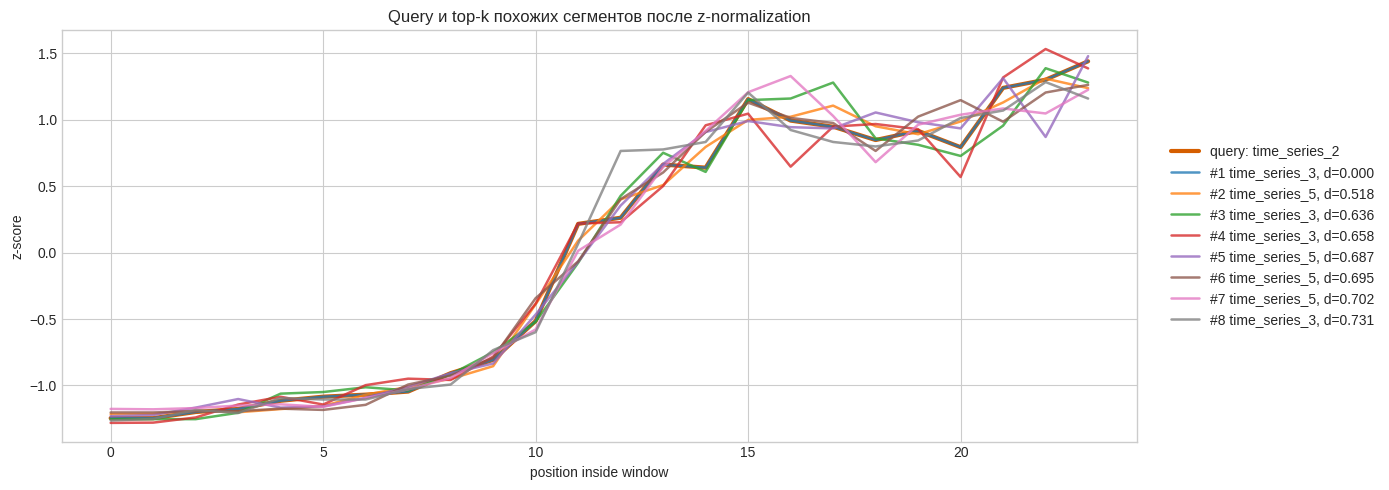

In [8]:
def z_norm(values: pd.Series | np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    std = np.nanstd(arr)
    if not np.isfinite(std) or std == 0:
        return arr * 0
    return (arr - np.nanmean(arr)) / std


fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(query))

ax.plot(x, z_norm(query.values), color="#d55e00", linewidth=3, label=f"query: {source_series_id}")

for rank, row in enumerate(results.itertuples(index=False), start=1):
    segment = searcher.get_segment(row.series_id, int(row.start_idx), int(row.end_idx))
    ax.plot(x, z_norm(segment.values), linewidth=1.8, alpha=0.78, label=f"#{rank} {row.series_id}, d={row.distance:.3f}")

ax.set_title("Query и top-k похожих сегментов после z-normalization")
ax.set_xlabel("position inside window")
ax.set_ylabel("z-score")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()